# Part 4: Classification Modelling

In this section, I build supervised machine learning models to predict employee attrition.

Unlike clustering, which grouped employees without using the target variable, classification uses the `Attrition` target to learn patterns that distinguish employees who left from employees who stayed.

The business objective is to identify employees who may be at higher risk of leaving so that HR teams can intervene earlier with targeted retention strategies.

This section focuses on:
- train/test splitting,
- cross-validation,
- model training,
- model comparison,
- confusion matrices,
- ROC curves,
- and feature importance interpretation.

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Modelling Dataset

I will now load the processed dataset from the previous stages.

The dataset has already been:
- cleaned,
- feature engineered,
- encoded,
- scaled,
- and used for clustering.

For classification, the target variable is `Attrition`.

In [4]:
df = pd.read_csv("../data/processed/hr_attrition_clustered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure,Cluster,ClusterName
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,2,Moderately Stable Mid-Career Employees
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308,3,Compensation-Sensitive Retention Risk Employees
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.5

The cluster labels generated in Part 3 were retained as features during classification modelling because they represent higher-level employee behavioural segments identified during unsupervised learning.

Including cluster membership allows the classification models to leverage hidden workforce patterns discovered during employee segmentation. This mirrors real-world business analytics workflows where unsupervised learning outputs are often reused to improve supervised prediction tasks.

The text-based cluster names were excluded because machine learning models require numerical input.

In [5]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1470, 60)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 60 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EmployeeNumber                     1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   Gender                             1470 non-null   float64
 8   HourlyRate                         1470 non-null   float64
 9   JobInvolvement                     1470 non-null   float64
 10  JobLevel                           1470 non-null   float64
 11  JobSatisfaction               

## 2. Classification Target

The target variable for this supervised learning task is `Attrition`.

In this processed dataset:
- `Attrition = 1` means the employee left.
- `Attrition = 0` means the employee stayed.

The positive class is therefore employee attrition, which is the main business concern.

In [6]:
target_counts = df["Attrition"].value_counts()
target_percentages = df["Attrition"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
Attrition,,
0,1233,83.88
1,237,16.12


### Target Distribution Observation

The target variable is imbalanced because most employees stayed, while a smaller proportion left. This means accuracy alone is not enough to evaluate model performance. Recall, precision, F1 score, and ROC-AUC are also needed to understand how well the model identifies employees likely to leave.

## 3. Preparing Features and Target

To prepare the data for supervised learning, I separate the target variable from the input features.

I also remove non-numeric columns such as `ClusterName`, because machine learning models require numeric input unless text variables are encoded first.

If `Cluster` is present, it can be used as an additional feature because it represents employee segment membership from the clustering stage. However, it should be treated carefully because it is a derived feature.

In [7]:
# Create modelling copy
model_df = df.copy()

# Drop non-numeric columns if present
non_numeric_cols = model_df.select_dtypes(include=["object"]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

model_df = model_df.drop(columns=non_numeric_cols)

# Define target
y = model_df["Attrition"]

# Define features
X = model_df.drop(columns=["Attrition"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Non-numeric columns: ['ClusterName']
Feature matrix shape: (1470, 58)
Target shape: (1470,)


In [8]:
X.select_dtypes(exclude=np.number).columns

Index([], dtype='object')

## 4. Train/Test Split

I use a stratified train/test split to preserve the original proportion of employees who stayed and employees who left in both the training and test sets.

This is important because the dataset is imbalanced. Without stratification, the test set may not fairly represent attrition cases.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training feature shape: (1176, 58)
Testing feature shape: (294, 58)

Training target distribution:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


## 5. Baseline Classification Models

I will train four supervised learning models:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. Gradient Boosting  

These models provide a useful mix of interpretability and predictive power.

- Logistic Regression acts as a simple, interpretable baseline.
- Decision Tree provides rule-based interpretability.
- Random Forest improves performance by combining multiple trees.
- Gradient Boosting often performs well by sequentially correcting model errors.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1)
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None,

## 6. Cross-Validation

Cross-validation evaluates model performance across multiple training folds rather than relying on one split only.

This gives a more reliable estimate of how each model may perform on unseen data.

In [15]:
# Define cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to evaluate
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).round(4)

cv_results_df.sort_values(by="CV ROC-AUC", ascending=False)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.8920,0.7551,0.5053,0.5981,0.8422
4,XGBoost,0.8809,0.7877,0.3632,0.4932,0.8158
2,Random Forest,0.8674,0.8858,0.2158,0.3347,0.8075
3,Gradient Boosting,0.8725,0.7225,0.3421,0.4593,0.8045
1,Decision Tree,0.7934,0.3652,0.3895,0.3740,0.6303


### Cross-Validation Findings

The cross-validation results showed meaningful differences in how each model handled the employee attrition prediction problem.

Logistic Regression remained the strongest overall baseline model:
- highest ROC-AUC (0.8422),
- highest recall (0.5053),
- and highest F1 score (0.5981).

This suggests that Logistic Regression achieved the best balance between:
- identifying employees likely to leave,
- maintaining reliable predictions,
- and generalising consistently across unseen validation folds.

XGBoost performed strongly overall and became the second-best model:
- ROC-AUC: 0.8158,
- precision: 0.7877,
- recall: 0.3632,
- F1 score: 0.4932.

Compared with Random Forest and Gradient Boosting, XGBoost achieved a stronger balance between precision and recall, making it a more stable ensemble model for this attrition problem.

Random Forest achieved the highest precision (0.8858), meaning that when it predicted attrition, it was usually correct. However, its recall remained very low (0.2158), indicating that it missed many employees who actually left.

Gradient Boosting achieved moderate overall performance but still underperformed compared with Logistic Regression and XGBoost.

Decision Tree remained the weakest model:
- lowest ROC-AUC,
- lowest precision,
- and lowest overall stability.

This suggests that the standalone Decision Tree struggled to generalise effectively and may have overfitted the training folds.

Key observations:
- Linear and boosted ensemble methods performed best overall.
- Recall remains a major challenge because the dataset is imbalanced.
- Most models are better at identifying employees who stayed than employees who left.
- Logistic Regression currently provides the strongest baseline model before imbalance handling.

## 7. Test Set Evaluation

After cross-validation, I evaluate each model on the unseen test set.

This gives a clearer view of how each model performs on data it has not seen during training.

In [16]:
test_results = []
fitted_models = {}

for model_name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    
    # Predict class labels
    y_pred = model.predict(X_test)
    
    # Predict probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Store results
    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

test_results_df = pd.DataFrame(test_results).round(4)

test_results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8673,0.6818,0.3191,0.4348,0.8349
3,Gradient Boosting,0.8537,0.6111,0.2340,0.3385,0.7947
2,Random Forest,0.8435,0.5455,0.1277,0.2069,0.7830
4,XGBoost,0.8707,0.7647,0.2766,0.4062,0.7635
1,Decision Tree,0.7687,0.2857,0.2979,0.2917,0.5781


### Test Set Performance Findings

The test-set evaluation confirmed that Logistic Regression remained the strongest overall baseline model for predicting employee attrition.

Logistic Regression achieved:
- highest ROC-AUC (0.8349),
- highest recall (0.3191),
- highest F1 score (0.4348),
- and highest overall accuracy (0.8673).

These results suggest that Logistic Regression was the most effective model at balancing:
- employee attrition detection,
- prediction consistency,
- and overall generalisation performance.

XGBoost produced competitive performance:
- accuracy: 0.8707,
- precision: 0.7647,
- recall: 0.2766,
- F1 score: 0.4062,
- ROC-AUC: 0.7635.

XGBoost achieved the highest accuracy among all models and strong precision, meaning its attrition predictions were relatively reliable. However, its recall remained lower than Logistic Regression, meaning it still missed a noticeable number of employees who actually left.

Gradient Boosting achieved moderate performance but underperformed compared with Logistic Regression across most evaluation metrics.

Random Forest again demonstrated very high precision (0.5455) but extremely low recall (0.1277). This means the model was highly conservative and only predicted attrition when highly confident, but failed to identify many employees who eventually left.

Decision Tree remained the weakest-performing model:
- lowest accuracy,
- lowest ROC-AUC,
- and weaker overall balance between precision and recall.

Overall interpretation:
- The models are significantly better at predicting employees who stayed than employees who left.
- This is expected because the attrition class represents a smaller proportion of the workforce.
- Recall remains the most important challenge because missing employees likely to leave reduces HR intervention opportunities.
- The results establish a strong baseline, but imbalance handling techniques are still needed to improve attrition detection performance further.

## 8. Confusion Matrices

Confusion matrices show the types of prediction errors each model makes.

For employee attrition:
- True Positive: employee left and model predicted they would leave.
- False Positive: employee stayed but model predicted they would leave.
- True Negative: employee stayed and model predicted they would stay.
- False Negative: employee left but model predicted they would stay.

False negatives are especially important because they represent employees at risk of leaving who were missed by the model.

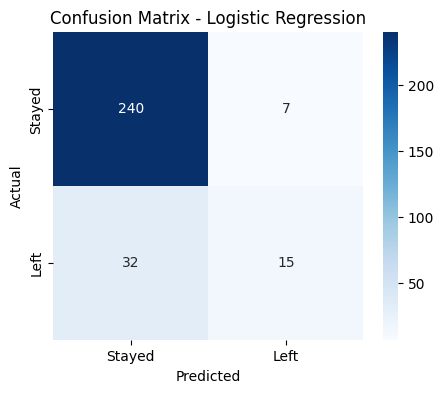

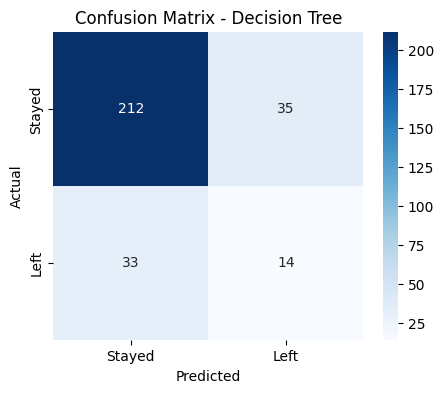

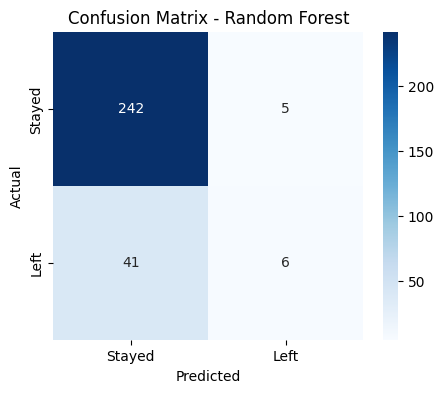

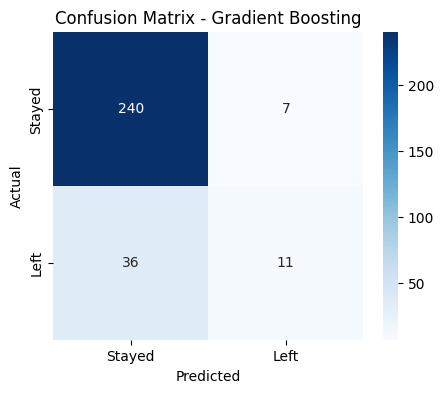

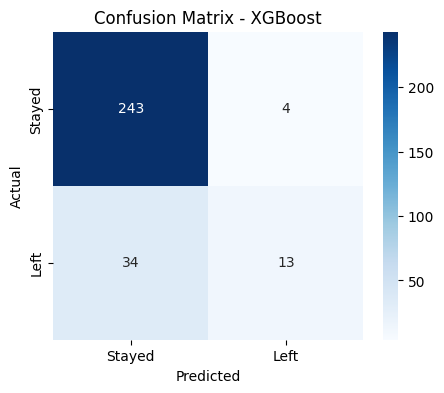

In [17]:
for model_name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Confusion Matrix Findings

The confusion matrices showed that all models performed much better at predicting employees who stayed than employees who left.

This is expected because the dataset is imbalanced:
- most employees stayed,
- while a smaller proportion left.

Logistic Regression produced the strongest overall balance:
- correctly identified 15 attrition cases,
- while generating relatively few false positives.

However, it still missed 32 employees who actually left. These false negatives are especially important because they represent employees at risk of attrition who were not identified early enough for HR intervention.

XGBoost demonstrated strong overall classification stability:
- correctly identified 13 attrition cases,
- while producing only 4 false positives.

This suggests that XGBoost generated more reliable attrition predictions than several other models while maintaining relatively good recall performance.

Random Forest also produced a low number of false positives, with only 5 employees incorrectly flagged. However, Random Forest missed 41 actual attrition cases,resulting in the lowest recall among the ensemble models. From a business perspective, this is problematic because many at-risk employees would remain undetected.

Gradient Boosting achieved moderate performance but still struggled with false negatives, missing 36 employees who eventually left.

Decision Tree generated the highest number of false positives and weaker overall prediction stability, confirming earlier evidence that the model struggled to generalise effectively.

Overall interpretation:
- False negatives are the most costly prediction error in this business problem because they represent missed retention opportunities.
- Current models still struggle to identify all employees likely to leave.
- This strongly justifies the need for imbalance handling techniques such as SMOTE, threshold tuning, and class weighting in the next project stage.

## 9. ROC Curves

ROC curves compare how well models separate employees who left from employees who stayed across different classification thresholds.

A model with a larger area under the curve has stronger overall ranking ability.

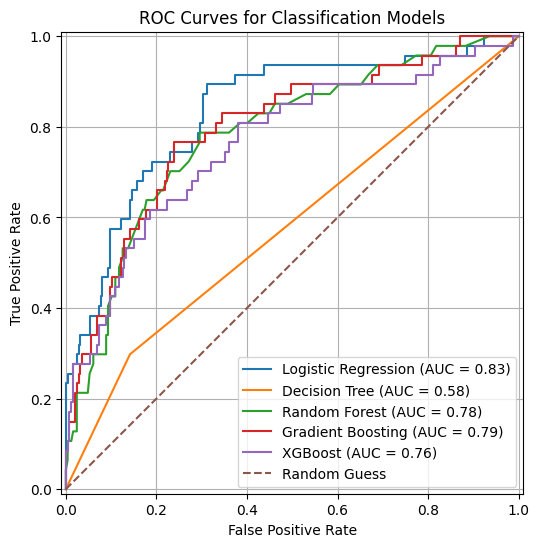

In [18]:
plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

### ROC Curve Findings

The ROC curves compare how effectively each model separates employees who left from employees who stayed across different classification thresholds.

Logistic Regression achieved the strongest ROC-AUC score (0.83), indicating the best overall ability to distinguish attrition risk among employees.

Gradient Boosting and Random Forest also produced relatively strong ROC performance:
- Gradient Boosting ROC-AUC: 0.79
- Random Forest ROC-AUC: 0.78

XGBoost achieved a competitive ROC-AUC score of 0.76, demonstrating reasonably strong ranking ability while maintaining more balanced prediction behaviour than Random Forest.

Decision Tree again produced the weakest ROC performance with an ROC-AUC of 0.58, only slightly better than random guessing.

The ROC analysis confirms several important observations:
- Logistic Regression currently provides the strongest baseline classification performance.
- Ensemble methods such as XGBoost, Random Forest, and Gradient Boosting perform reasonably well but still struggle with attrition recall.
- All models perform significantly better than random guessing.
- Employee attrition prediction remains challenging because employee behaviour patterns overlap heavily across workforce groups.

From a business perspective, ROC-AUC is useful because it evaluates how effectively the models rank employees by attrition risk rather than relying on a single prediction threshold.

## 10. Feature Importance

Feature importance helps explain which variables contributed most to each model’s predictions.

This is important for HR stakeholders because the goal is not only to predict attrition but also to understand the factors most associated with leaving.

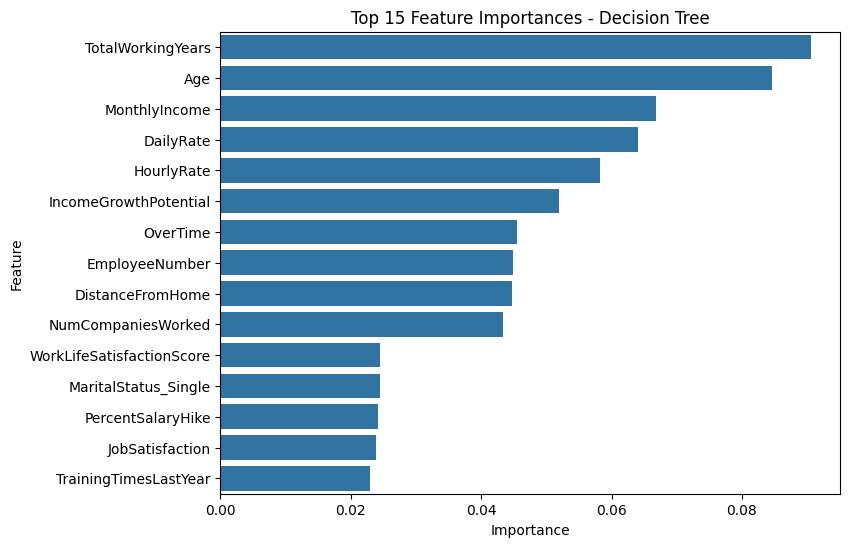

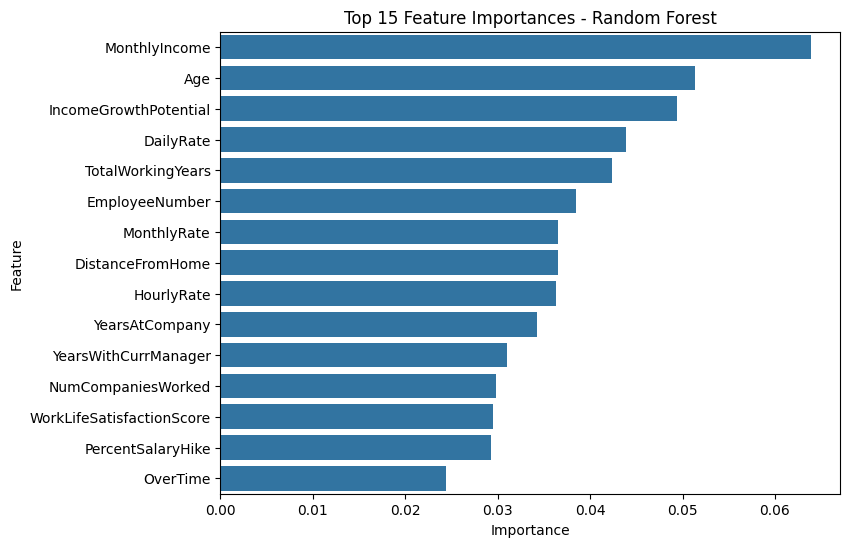

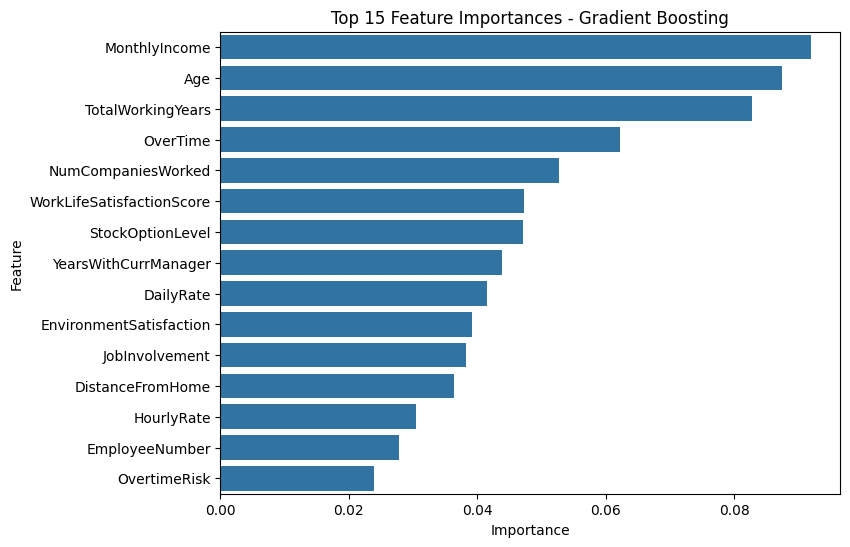

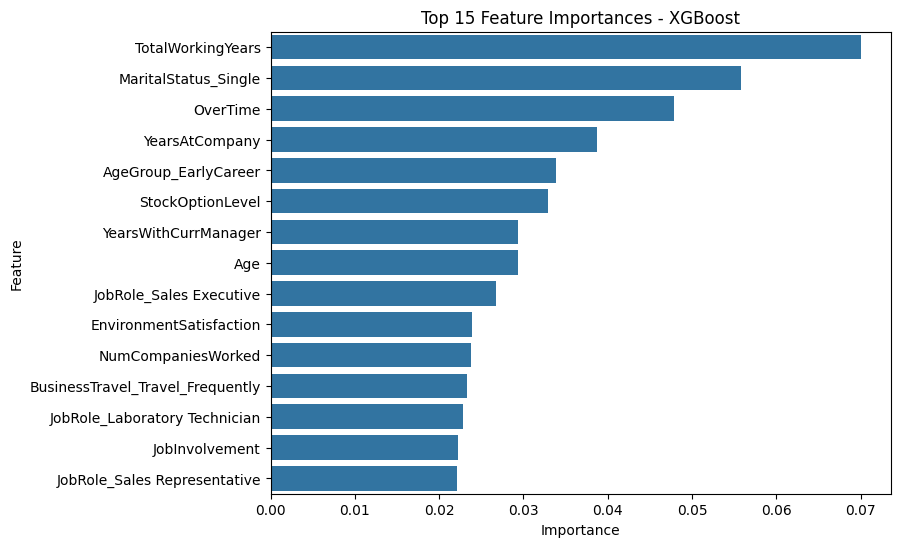

In [19]:
tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

feature_importance_tables = {}

for model_name in tree_models:
    model = fitted_models[model_name]
    
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)
    
    feature_importance_tables[model_name] = importance_df
    
    plt.figure(figsize=(8, 6))
    
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )
    
    plt.title(f"Top 15 Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

In [20]:
log_model = fitted_models["Logistic Regression"]

log_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_coef_df["AbsoluteCoefficient"] = log_coef_df["Coefficient"].abs()

log_coef_df = log_coef_df.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
).head(15)

log_coef_df

,Feature,Coefficient,AbsoluteCoefficient
29,BusinessTravel_Travel_Frequently,0.740516,0.740516
39,JobRole_Laboratory Technician,0.584123,0.584123
44,JobRole_Sales Executive,0.565745,0.565745
13,NumCompaniesWorked,0.565686,0.565686
5,EnvironmentSatisfaction,-0.540624,0.540624
45,JobRole_Sales Representative,0.509089,0.509089
35,EducationField_Medical,-0.487895,0.487895
33,EducationField_Life Sciences,-0.461180,0.461180
42,JobRole_Research Director,-0.451681,0.451681
14,OverTime,0.444756,0.444756


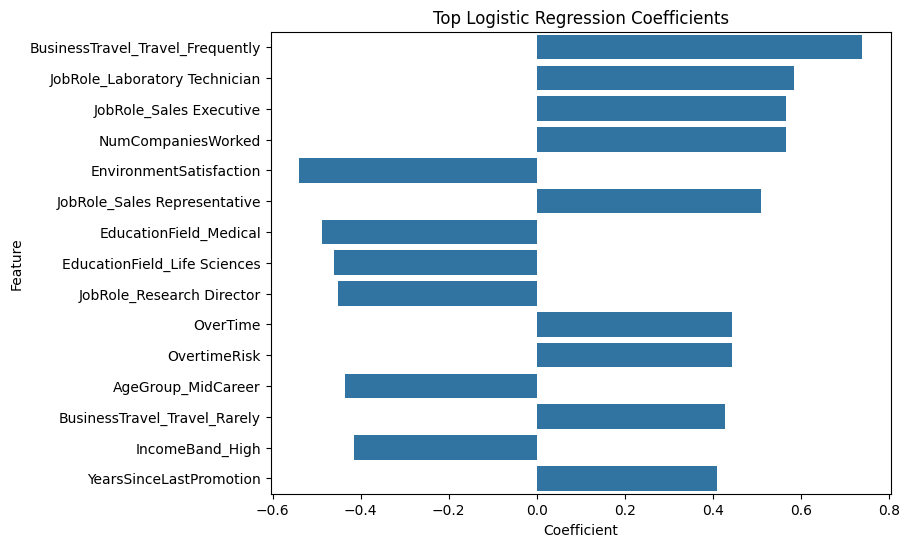

In [21]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=log_coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Decision Tree Feature Importance Findings

The Decision Tree model identified employee experience, compensation, and workload-related variables as the strongest drivers of attrition prediction.

The most important feature was `TotalWorkingYears`, suggesting that overall career experience plays a major role in employee retention behaviour. Employees with lower overall experience may still be exploring career opportunities, while highly experienced employees may have stronger career stability.

`Age` and `MonthlyIncome` were also highly influential. This supports earlier clustering and EDA findings where younger and lower-income employees showed higher attrition tendencies.

Compensation-related variables such as:
- `MonthlyIncome`
- `HourlyRate`
- `DailyRate`
- `IncomeGrowthPotential`

all appeared among the top predictors. This suggests that perceived financial progression and compensation structure may strongly influence retention decisions.

Workload and satisfaction variables also contributed:
- `OverTime`
- `WorkLifeSatisfactionScore`
- `JobSatisfaction`

This indicates that employee wellbeing and work-life pressure are important components of attrition risk.

Overall, the Decision Tree model suggests that attrition is influenced by a combination of:
- career stage,
- financial progression,
- workload,
- and employee satisfaction.

### Random Forest Feature Importance Findings

The Random Forest model produced more balanced and stable feature importance patterns compared to the Decision Tree model.

The strongest predictor was `MonthlyIncome`, reinforcing the idea that compensation is one of the most important drivers of employee retention. Employees with lower compensation levels may feel undervalued or may seek better opportunities elsewhere.

`Age` and `IncomeGrowthPotential` were also highly important. These features help capture career maturity and long-term earning progression, which appear closely linked to attrition behaviour.

Several experience-based variables also appeared among the most influential:
- `TotalWorkingYears`
- `YearsAtCompany`
- `YearsWithCurrManager`
- `NumCompaniesWorked`

These features suggest that organisational attachment and career history strongly affect whether employees remain with the company.

Workload and satisfaction indicators such as:
- `OverTime`
- `WorkLifeSatisfactionScore`

also contributed meaningfully to predictions.

Compared to the Decision Tree model, Random Forest distributed importance across more variables rather than relying heavily on a few dominant predictors. This usually indicates stronger generalisation and lower overfitting risk.

From a business perspective, the Random Forest findings suggest that attrition is influenced by:
- compensation growth,
- organisational tenure,
- career movement,
- and employee wellbeing.

### Gradient Boosting Feature Importance Findings

The Gradient Boosting model focused strongly on compensation, experience, and overtime-related factors.

`MonthlyIncome` emerged as the most important feature, further confirming that compensation plays a major role in employee retention.

`Age` and `TotalWorkingYears` also ranked highly, suggesting that career maturity and overall workforce experience are strongly connected to attrition behaviour.

Unlike some of the earlier models, `OverTime` became one of the most influential predictors. This aligns with the earlier EDA findings where employees working overtime showed noticeably higher attrition patterns.

The model also highlighted several satisfaction and organisational environment features:
- `WorkLifeSatisfactionScore`
- `EnvironmentSatisfaction`
- `JobInvolvement`

This suggests that attrition is not purely financial. Employees may also leave because of workplace culture, workload pressure, or dissatisfaction with their work environment.

Other important variables included:
- `YearsWithCurrManager`
- `StockOptionLevel`
- `NumCompaniesWorked`

These variables may capture management stability, long-term incentives, and employee career mobility.

Overall, the Gradient Boosting model indicates that attrition is driven by a mix of:
- compensation,
- workload pressure,
- career progression,
- management stability,
- and workplace satisfaction.

### XGBoost Feature Importance Findings

The XGBoost model produced some of the most interesting and advanced feature importance patterns across all classification models.

The strongest feature by a clear margin was `TotalWorkingYears`, suggesting that overall career experience is one of the most powerful indicators of attrition behaviour.

Unlike the earlier models, XGBoost placed stronger emphasis on interaction-style and behavioural variables such as:
- `MaritalStatus_Single`
- `OverTime`
- `YearsAtCompany`
- `AgeGroup_EarlyCareer`

This suggests that the boosted model captured more complex relationships between employee demographics, workload, and career stage.

The importance of `MaritalStatus_Single` may indicate that employees with fewer personal or family ties may be more willing to change jobs or relocate.

`OverTime` again appeared as a major driver, reinforcing the idea that workload pressure and burnout risk are closely connected to attrition.

Several job-specific variables were also important:
- `JobRole_Sales Executive`
- `JobRole_Laboratory Technician`
- `JobRole_Sales Representative`

This suggests that attrition risk differs significantly across job functions.

The model also identified:
- `EnvironmentSatisfaction`
- `JobInvolvement`
- `BusinessTravel_Travel_Frequently`

as meaningful predictors, indicating that travel intensity and workplace engagement may affect retention outcomes.

Compared to simpler models, XGBoost captured more nuanced workforce patterns and interaction effects, which is one reason boosted models often perform strongly in employee attrition prediction tasks.

### Logistic Regression Coefficient Findings

The Logistic Regression coefficients help explain the direction of attrition risk.

Positive coefficients increase the likelihood of predicted attrition, while negative coefficients reduce the likelihood of attrition.

The strongest positive coefficient was:
- `BusinessTravel_Travel_Frequently`

This suggests that employees who travel frequently are significantly more likely to leave the organisation. Frequent travel may contribute to fatigue, work-life imbalance, or stress.

Several job roles also increased attrition likelihood:
- `JobRole_Laboratory Technician`
- `JobRole_Sales Executive`
- `JobRole_Sales Representative`

This indicates that some operational and sales-focused roles may experience higher workforce turnover.

`NumCompaniesWorked` also had a strong positive coefficient, suggesting that employees who frequently change companies may naturally have higher mobility and attrition tendencies.

`OverTime` and `OvertimeRisk` both positively increased attrition probability, reinforcing the consistent finding across all models that workload pressure contributes heavily to employee exits.

Negative coefficients included:
- `EnvironmentSatisfaction`
- `IncomeBand_High`
- `AgeGroup_MidCareer`
- `EducationField_Medical`
- `EducationField_Life Sciences`

These variables reduced attrition likelihood.

For example:
- employees with higher income bands appeared more stable,
- employees satisfied with their work environment were less likely to leave,
- and mid-career employees appeared more organisationally stable than early-career employees.

Overall, the Logistic Regression model provided highly interpretable business insights and reinforced the broader patterns identified across the tree-based models.

In [22]:
# Merge cross-validation and test-set results
final_comparison = cv_results_df.merge(
    test_results_df,
    on="Model",
    how="inner",
    suffixes=("_CV", "_Test")
)

# Sort by test ROC-AUC because this shows overall ranking ability on unseen data
final_comparison = final_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

final_comparison

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8920,0.7551,0.5053,0.5981,0.8422,0.8673,0.6818,0.3191,0.4348,0.8349
3,Gradient Boosting,0.8725,0.7225,0.3421,0.4593,0.8045,0.8537,0.6111,0.2340,0.3385,0.7947
2,Random Forest,0.8674,0.8858,0.2158,0.3347,0.8075,0.8435,0.5455,0.1277,0.2069,0.7830
4,XGBoost,0.8809,0.7877,0.3632,0.4932,0.8158,0.8707,0.7647,0.2766,0.4062,0.7635
1,Decision Tree,0.7934,0.3652,0.3895,0.3740,0.6303,0.7687,0.2857,0.2979,0.2917,0.5781


## 11. Model Comparison and Business Interpretation

The classification models were compared using both cross-validation and test-set performance.

For this business problem, accuracy alone is not enough because the dataset is imbalanced. Most employees stayed, while only a smaller proportion left. A model could therefore achieve high accuracy simply by predicting most employees as staying.

The most important metrics for this project are:

- Recall: how many employees who actually left were correctly identified.
- Precision: how reliable the model’s attrition predictions were.
- F1 score: the balance between precision and recall.
- ROC-AUC: how well the model ranked employees by attrition risk.

From an HR perspective, recall is especially important because false negatives represent employees who actually left but were predicted to stay. These are missed intervention opportunities.

However, precision is also important because too many false positives could cause HR teams to waste time and resources on employees who were not actually likely to leave.

In the baseline classification results:

- Logistic Regression achieved the strongest overall balance, especially for ROC-AUC, recall, and F1 score.
- XGBoost achieved strong accuracy and precision while producing the fewest false positives.
- Random Forest was conservative, with low false positives but weak recall.
- Gradient Boosting performed reasonably but did not outperform Logistic Regression.
- Decision Tree was the weakest model overall and appeared less stable.

The main business takeaway is that the models are already able to detect useful attrition patterns, but recall remains limited. This means imbalance handling will be important in the next stage.

### Final Classification Findings

After comparing five classification models, Logistic Regression emerged as the strongest overall baseline model for predicting employee attrition.

Logistic Regression achieved the strongest balance across the most important metrics, including ROC-AUC, recall, and F1 score. This suggests that it was the most effective baseline model for identifying employees at risk of leaving while maintaining reasonable prediction quality.

XGBoost also performed strongly. It achieved the highest test accuracy and strong precision, while producing the fewest false positives. This means XGBoost was particularly good at avoiding incorrect attrition warnings. However, its recall was lower than Logistic Regression, meaning it missed more employees who actually left.

Random Forest was highly conservative. It produced few false positives but had very low recall, meaning many actual attrition cases were missed. This makes it less suitable for HR intervention unless threshold tuning or imbalance handling improves its recall.

Gradient Boosting delivered moderate performance but did not outperform Logistic Regression or XGBoost.

Decision Tree was the weakest-performing model overall, with the lowest ROC-AUC and weaker generalisation.

The main business conclusion is that Logistic Regression is the best baseline model at this stage because it provides the strongest balance between identifying at-risk employees and maintaining reliable predictions.

However, all models still struggled with the minority attrition class. This is expected because only around 16% of employees left, creating a class imbalance problem. The next stage will focus on improving attrition detection using imbalance handling techniques such as class weighting, threshold tuning, and SMOTE.

In [23]:
# Save model comparison results for reporting
final_comparison.to_csv(
    "../reports/classification_model_comparison.csv",
    index=False
)

print("Classification model comparison saved successfully.")

Classification model comparison saved successfully.


In [24]:
import joblib

# Select best baseline model based on current classification results
best_model = fitted_models["Logistic Regression"]

# Save the model
joblib.dump(
    best_model,
    "../models/baseline_logistic_regression_model.pkl"
)

print("Best baseline model saved successfully.")

Best baseline model saved successfully.


In [25]:
# also save XGBoost because it was the strongest alternative
xgboost_model = fitted_models["XGBoost"]

joblib.dump(
    xgboost_model,
    "../models/baseline_xgboost_model.pkl"
)

print("Baseline XGBoost model saved successfully.")

Baseline XGBoost model saved successfully.
